# 09. 모아 둔 것을 정문으로 연다 — 재무 · 거시 · 공시 텍스트

> 2026-09-11 · 이동원 · 결론 문서:
> [데이터파트 v4.5](../../docs/데이터파트/version4.5/명세서.md) ·
> [기능명세 v1.9 중기·장기 원천 정문](../../docs/기능명세/version1.9/중기장기_원천_정문.md)

재무 66만 행 · 거시 1.8만 행 · 공시 155만 행 · 제목 점수 1.9만 행을 모아 두었는데, 피처·모델이
꺼내 쓸 **정문이 없었습니다.** `supply/` 에서 이 넷을 읽는 곳은 품질 원장(건수 세기) 하나뿐이었고
`features/` 에서는 0건이었습니다.

이 노트북은 새로 연 정문 셋을 **실제 팀 유니버스** — 매 거래일 업종지수 시가총액 상위 10 ×
업종별 KOSPI 보통주 시가총액 상위 5 (`build_sector_candidate_frame`) — 에 붙여 보고 답합니다.

1. 무엇이 **몇 %** 채워지나 — 재무 · 거시 · 텍스트
2. 결산기로 붙이면 **몇 %의 행이 미래를 보나** — 실데이터 음성 대조군
3. 정정본 26% 가 **무엇을 잃게 하나**
4. 업종·주권종류 **하루 누수**를 고치면 팀 유니버스가 얼마나 바뀌나
5. 피처 파트는 **이렇게 쓰면 된다**

🔴 세 정문의 규칙은 하나입니다 — **행 T 에 보이는 것은 `known_at <= T` 인 것뿐.**
`known_at` 은 재무·텍스트는 *접수일 다음 거래일*, 거시는 *발표 규칙으로 계산한 날* 입니다.

## 결론 한눈에 (실측 2026-09-11 · 월말 116일 × 후보 5,703행)

| 질문 | 답 |
|---|---|
| 재무가 붙는 비율 | 후보 행의 **70.8%** — 2015년은 FY2014 를 받지 않아 0%(정상) · 2024년 92.5% |
| 낡은 재무 | 결산기 끝에서 15개월 넘은 보고서가 붙은 행 **4.5%**(257행 · 32종) |
| 결산기로 붙이면 | 후보 행의 **23.2%**(1,324행)가 미래 보고서를 본다 · 정문은 **0** |
| 원본 접수일로 당기면 | **9.1%**(516행)가 정정된 숫자를 원본 날짜에 본다 |
| 거시 | 9지표 모두 **100%** 채워진다 |
| 공시 텍스트 | 그날 새 공시가 있는 후보 행 **20~36%** |
| 하루 누수 수정 | 스냅샷 날 15일 중 **12일** 후보가 바뀌고 합계 **25종목** |

In [1]:
import sqlite3
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager

ROOT = Path.cwd()
while not (ROOT / "supply").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from common.paths import krx_db_path  # noqa: E402, I001
from common.trading_calendar import load_session_days  # noqa: E402
from supply import attach_financial, attach_macro, attach_text, financial, macro  # noqa: E402
from supply.sector import attach_industry, resolve_duplicates, snapshots  # noqa: E402
from supply.stock_training_universe import build_sector_candidate_frame  # noqa: E402
from supply.text import text_as_of  # noqa: E402
from supply.universe import attach_security_type  # noqa: E402

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)


def 한글폰트_설정() -> str:
    # ① 한글 폰트  ② fallback 체인 (맑은 고딕에는 U+2212 가 없다)  ③ unicode_minus 끄기
    후보 = ["Malgun Gothic", "NanumGothic", "NanumBarunGothic", "AppleGothic",
            "Noto Sans CJK KR", "Gulim"]
    있는것 = {f.name for f in font_manager.fontManager.ttflist}
    찾음 = next((n for n in 후보 if n in 있는것), None)
    if 찾음 is None:
        print("🔴 한글 폰트가 없다 — 그림의 한글이 □ 로 나온다.")
        print("   Colab·Linux: !apt-get install -y fonts-nanum && fc-cache -fv")
        return ""
    plt.rcParams["font.family"] = [찾음, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    plt.rcParams["figure.dpi"] = 110
    return 찾음


폰트 = 한글폰트_설정()
con = sqlite3.connect(f"file:{krx_db_path()}?mode=ro", uri=True)
AS_OF = "2024-09-01"   # 개발구간 끝(20240831)까지 알 수 있었던 시점
HOLDOUT = "20240901"
커밋 = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True,
                    text=True, cwd=ROOT).stdout.strip()
print(f"한글 폰트 {폰트 or '없음'} · 커밋 {커밋} · Python {sys.version.split()[0]}")
print(f"스키마 v{con.execute('PRAGMA user_version').fetchone()[0]} · as_of {AS_OF}")

한글 폰트 Malgun Gothic · 커밋 f5bcd82 · Python 3.12.13
스키마 v16 · as_of 2024-09-01


---

## 1. 원천 넷 — 무엇이 얼마나 있나

`text_signal` 에만 시점 칸이 없습니다. 고유 제목마다 한 줄이라 같은 제목이 2010년에도 2026년에도
나오기 때문입니다. 시점은 그 제목을 단 **공시의 접수일**에서 옵니다.

In [2]:
원천 = []
for 표, 칸 in [("dart_financial", "rcept_dt"), ("macro_series", "known_at"),
               ("dart_disclosure", "rcept_dt"), ("text_signal", None)]:
    행 = con.execute(f"SELECT COUNT(*) FROM {표}").fetchone()[0]
    lo, hi = (con.execute(f"SELECT MIN({칸}), MAX({칸}) FROM {표}").fetchone()
              if 칸 else ("-", "-"))
    원천.append({"표": 표, "행": f"{행:,}", "시점 칸": 칸 or "없음(공시에서 온다)",
                 "처음": lo, "끝": hi})
display(pd.DataFrame(원천))

,표,행,시점 칸,처음,끝
0,dart_financial,"662,933",rcept_dt,20150923,20260814
1,macro_series,"17,864",known_at,20090828,20260910
2,dart_disclosure,"1,555,556",rcept_dt,20100104,20260904
3,text_signal,"18,600",없음(공시에서 온다),-,-


---

## 2. 팀 유니버스 — 월말 거래일 116일에서 후보를 만든다

채움률은 **팀이 실제로 학습하는 행**에서 재야 뜻이 있습니다. 모델 파트의 후보 규칙
(`supply.stock_training_universe.build_sector_candidate_frame`)을 그대로 씁니다. 날마다
후보는 그날 자료만으로 정해지므로, 2015-01 ~ 2024-08 의 **월말 거래일**만 뽑아도 같은 규칙입니다.

업종(`attach_industry`)과 주권종류(`attach_security_type`)는 **오늘 고친** 규칙
(그 행의 날짜까지 알게 된 것)으로 붙입니다 — 7절에서 고치기 전과 비교합니다.

In [3]:
달력 = np.array(sorted(load_session_days()))
월말 = pd.Series(달력).groupby(pd.Series(달력).str[:6]).max()
표본날 = [d for d in 월말 if "20150101" <= d < HOLDOUT]


def 코스피_시세(날들):
    자리 = ",".join("?" * len(날들))
    daily = pd.read_sql_query(
        "SELECT bas_dd, code, name, market, market_cap FROM daily_price "
        f"WHERE market = 'KOSPI' AND bas_dd IN ({자리})", con, params=list(날들))
    index = pd.read_sql_query(
        "SELECT bas_dd, index_name, index_class, market_cap FROM index_price "
        f"WHERE bas_dd IN ({자리})", con, params=list(날들))
    return daily, index


def 고친_규칙으로_붙인다(daily):
    out = attach_industry(daily, as_of=AS_OF)
    해별 = [attach_security_type(s, as_of=AS_OF) for _, s in out.groupby(out["bas_dd"].str[:4])]
    return pd.concat(해별, ignore_index=True)


t0 = time.time()
daily, index = 코스피_시세(표본날)
daily = 고친_규칙으로_붙인다(daily)
후보 = build_sector_candidate_frame(daily, index, holdout_start=HOLDOUT)
# 후보 표의 code 는 pandas "string"(pd.NA) 이다. DB 에서 읽은 표는 기본 str(nan) 이라
# merge_asof 의 by 열쇠로 섞으면 dtype 이 달라 멈춘다 — 이 노트북의 대조군만 맞춰 둔다.
# (정문 attach_* 다섯은 string 코드를 받아도 돈다 — 실측 2026-09-11)
후보["code"] = 후보["code"].astype(str)
하루후보 = 후보.groupby("bas_dd").size()
print(f"표본 {len(표본날)}일 · KOSPI 행 {len(daily):,} · 후보 {len(후보):,} · "
      f"{time.time() - t0:.0f}초")
print(f"하루 후보 수: 최소 {하루후보.min()} · 중앙값 {int(하루후보.median())} · "
      f"최대 {하루후보.max()}")

표본 116일 · KOSPI 행 105,965 · 후보 5,703 · 59초
하루 후보 수: 최소 48 · 중앙값 49 · 최대 50


---

## 3. 재무 — 무엇이 몇 % 채워지나

`attach_financial` 은 행마다 **그 행의 날짜까지 알게 된 보고서 중 결산이 가장 늦은 것**을 붙입니다.
DB 의 재무는 **사업보고서(연 1회) · FY2015 부터**라서, 2015년 행과 2016년 3월 이전 행에는 붙을
보고서가 없는 것이 정상입니다.

⚠️ 붙은 보고서가 **오래됐는지**는 `fin_period_end`(결산기 끝)로 봅니다. 다음 해 보고서가 아직
안 보이면 — 늦게 냈거나 정정본이라 정정일까지 안 보이면 — 그 앞 보고서가 "가장 최근" 으로 붙습니다.

In [4]:
t0 = time.time()
재무 = attach_financial(후보[["bas_dd", "code"]], as_of=AS_OF)
print(f"attach_financial {len(재무):,}행 · {time.time() - t0:.1f}초")

재무["해"] = 재무["bas_dd"].str[:4]
붙음 = 재무["fin_rcept_no"].notna()
경과 = (pd.to_datetime(재무["bas_dd"]) - pd.to_datetime(재무["fin_period_end"])).dt.days
연도별 = pd.DataFrame({
    "후보 행": 재무.groupby("해").size(),
    "재무 붙음 %": 붙음.groupby(재무["해"]).mean() * 100,
    "15개월 넘은 보고서 %": (경과 > 456).groupby(재무["해"]).mean() * 100,
    "정정본 %": 재무["fin_amended"].eq(True).groupby(재무["해"]).mean() * 100,
}).round(1)
display(연도별)
print(f"전체 — 붙음 {붙음.mean():.2%} · 15개월 넘음 {(경과 > 456).mean():.2%} · "
      f"정정본 {재무['fin_amended'].eq(True).mean():.2%}")

attach_financial 5,703행 · 3.0초


,후보 행,재무 붙음 %,15개월 넘은 보고서 %,정정본 %
해,,,,
2015,580,0.0,0.0,0.0
2016,588,54.8,0.0,18.4
2017,576,72.0,4.0,14.6
2018,588,78.7,5.4,15.6
2019,588,82.0,5.6,17.0
2020,588,79.6,3.9,13.8
2021,595,80.5,4.7,12.4
2022,600,86.8,10.3,16.3
2023,600,86.2,7.3,16.8


전체 — 붙음 70.79% · 15개월 넘음 4.51% · 정정본 15.40%


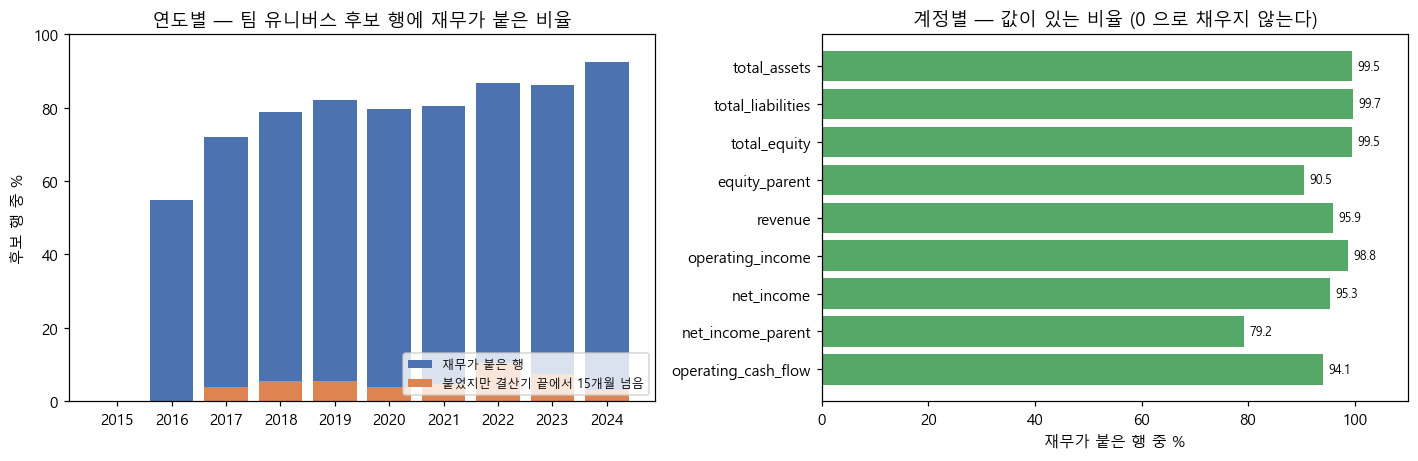

In [5]:
계정 = list(financial.FINANCIAL_ACCOUNTS)
계정채움 = 재무.loc[붙음, 계정].notna().mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
ax = axes[0]
ax.bar(연도별.index, 연도별["재무 붙음 %"], color="#4C72B0", label="재무가 붙은 행")
ax.bar(연도별.index, 연도별["15개월 넘은 보고서 %"], color="#DD8452",
       label="붙었지만 결산기 끝에서 15개월 넘음")
ax.set_ylim(0, 100)
ax.set_ylabel("후보 행 중 %")
ax.set_title("연도별 — 팀 유니버스 후보 행에 재무가 붙은 비율")
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
이름 = [c.replace("fin_", "") for c in 계정]
ax.barh(이름, 계정채움.to_numpy(), color="#55A868")
for y, v in enumerate(계정채움.to_numpy()):
    ax.text(v + 1, y, f"{v:.1f}", va="center", fontsize=8)
ax.set_xlim(0, 110)
ax.set_xlabel("재무가 붙은 행 중 %")
ax.set_title("계정별 — 값이 있는 비율 (0 으로 채우지 않는다)")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

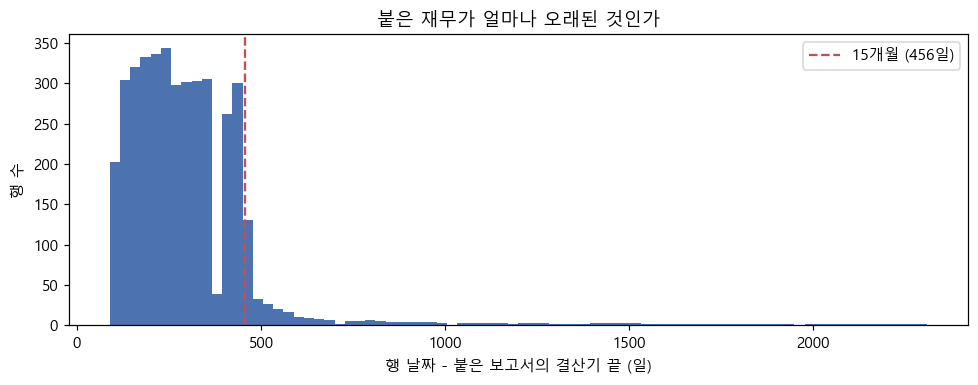

15개월 넘은 행 257 — 종목 32개


,bas_dd,code,fin_bsns_year,fin_rcept_dt,fin_report_nm
1461,20170731,051910,2015.0,20160516,[기재정정]사업보고서 (2015.12)
1514,20170831,035420,2015.0,20160330,사업보고서 (2015.12)
1880,20180330,000670,2015.0,20160516,[기재정정]사업보고서 (2015.12)
1910,20180430,047810,2016.0,20170814,[기재정정]사업보고서 (2016.12)
1941,20180531,000660,2016.0,20170331,사업보고서 (2016.12)
1964,20180531,006280,2016.0,20170331,사업보고서 (2016.12)
2042,20180731,009150,2016.0,20170331,사업보고서 (2016.12)
2278,20181130,004990,2016.0,20170404,[기재정정]사업보고서 (2016.12)


In [6]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(경과.dropna(), bins=80, color="#4C72B0")
ax.axvline(456, color="#C44E52", linestyle="--", label="15개월 (456일)")
ax.set_xlabel("행 날짜 - 붙은 보고서의 결산기 끝 (일)")
ax.set_ylabel("행 수")
ax.set_title("붙은 재무가 얼마나 오래된 것인가")
ax.legend()
fig.tight_layout()
plt.show()

오래됨 = 재무.loc[경과 > 456, ["bas_dd", "code", "fin_bsns_year", "fin_rcept_dt", "fin_report_nm"]]
print(f"15개월 넘은 행 {len(오래됨):,} — 종목 {오래됨['code'].nunique()}개")
display(오래됨.sort_values("bas_dd").groupby("code").tail(1).head(8))

**결과** — 후보 행의 **70.8%** 에 재무가 붙습니다. 2015년 0% 는 FY2014 를 받지 않았기 때문이고
(정상), 2017~2023년은 72~87%, 2024년은 92.5% 입니다. 결산기 끝에서 15개월 넘은 낡은 보고서가
붙은 행은 **4.5%**(257행 · 32종)입니다. 표의 LG화학(051910) 2017-07-31 행에는 FY2015 가 붙어
있습니다 — DB 의 FY2016 은 **정정본(2017-08-14 접수)** 뿐이라 그날 아직 보이지 않았습니다.
NAVER(035420) 2017-08-31 행도 같습니다(FY2016 정정본 2017-09-08 접수). 이런 행을 쓸지는
`fin_period_end` 로 피처 파트가 정합니다.

---

## 4. 음성 대조군 — 틀리게 붙이면 실제로 몇 %가 새나

검사가 정문과 같은 계산을 쓰면 정문이 틀릴 때 검사도 같이 틀려 초록이 나옵니다. 그래서 여기서는
**정문을 부르지 않고** 보고서 표를 직접 읽어 세 가지로 붙이고, 누수 여부는 저장된 접수일에서
**달력으로 따로** 다음 거래일을 셉니다.

| 구현 | 시점 규칙 | 기대 |
|---|---|---|
| 정문 | 접수일 다음 거래일 | 누수 0 |
| 대조군 ① | 결산기 끝 (제목의 `(YYYY.MM)` 말일) | 붉어야 한다 |
| 대조군 ② | 원본 최초 접수일 (정정 전) | 정정본 행에서 붉어야 한다 |

세 구현은 **시점 규칙 하나만** 다르고, 고르는 규칙(가장 늦은 결산)은 같습니다.

In [7]:
보고서 = pd.read_sql_query("""
  SELECT f.stock_code AS code, f.corp_code, f.bsns_year, f.rcept_no, f.rcept_dt,
         d.report_nm
  FROM (SELECT DISTINCT stock_code, corp_code, bsns_year, rcept_no, rcept_dt
        FROM dart_financial) f
  LEFT JOIN dart_disclosure d ON d.rcept_no = f.rcept_no
""", con)
보고서["tag"] = 보고서["report_nm"].str.extract(r"\((\d{4}\.\d{2})\)")[0]
보고서["결산기끝"] = (pd.to_datetime(보고서["tag"].str.replace(".", "") + "01", format="%Y%m%d")
                   + pd.offsets.MonthEnd(0)).dt.strftime("%Y%m%d")


def 다음거래일(날짜들):
    return 달력[np.searchsorted(달력, np.asarray(날짜들, dtype=str), side="right")]


보고서["알게된날"] = 다음거래일(보고서["rcept_dt"])

# 원본 최초 접수일 — 같은 회사·같은 결산연월 사업보고서 중 가장 이른 접수
목록 = pd.read_sql_query("""
  SELECT corp_code, report_nm, rcept_dt FROM dart_disclosure
  WHERE report_nm LIKE '%사업보고서%'
    AND corp_code IN (SELECT DISTINCT corp_code FROM dart_financial)
""", con)
목록["tag"] = 목록["report_nm"].str.extract(r"\((\d{4}\.\d{2})\)")[0]
첫접수 = 목록.dropna(subset=["tag"]).groupby(["corp_code", "tag"])["rcept_dt"].min()
보고서 = 보고서.merge(첫접수.rename("첫접수일").reset_index(), on=["corp_code", "tag"], how="left")
보고서["첫접수일"] = 보고서["첫접수일"].fillna(보고서["rcept_dt"])
보고서["원본_알게된날"] = 다음거래일(보고서["첫접수일"])

정정 = 보고서["report_nm"].str.startswith("[", na=False)
늦음 = (pd.to_datetime(보고서["rcept_dt"]) - pd.to_datetime(보고서["첫접수일"])).dt.days
print(f"보고서 {len(보고서):,} · 첫 제출본이 아닌 것 {정정.sum():,} ({정정.mean():.1%})")
print(f"정정일 - 원본 접수일: 중앙값 {늦음[정정].median():.0f}일 · 최대 {늦음[정정].max():.0f}일")

보고서 3,209 · 첫 제출본이 아닌 것 841 (26.2%)
정정일 - 원본 접수일: 중앙값 60일 · 최대 2378일


In [8]:
왼 = 후보[["bas_dd", "code"]].assign(_k=후보["bas_dd"].astype(int), _o=range(len(후보)))


def 열쇠로_붙인다(열쇠):
    오른 = (보고서.dropna(subset=[열쇠])
              .assign(_k=lambda f: f[열쇠].astype(int))
              .sort_values(["_k", "bsns_year"])
              .drop_duplicates(["code", "_k"], keep="last"))
    m = pd.merge_asof(왼.sort_values("_k"), 오른[["_k", "code", "rcept_no", "rcept_dt"]],
                      on="_k", by="code", direction="backward")
    return m.sort_values("_o").reset_index(drop=True)


def 샌_행(붙인, 접수일칸):
    있음 = 붙인[접수일칸].notna()
    알게된날 = pd.Series(pd.NA, index=붙인.index, dtype="object")
    알게된날[있음] = 다음거래일(붙인.loc[있음, 접수일칸])
    return 있음 & (알게된날 > 붙인["bas_dd"]), 알게된날


정문샘, _ = 샌_행(재무.rename(columns={"fin_rcept_dt": "rcept_dt"}), "rcept_dt")
결산기로 = 열쇠로_붙인다("결산기끝")
결산샘, 결산알게된날 = 샌_행(결산기로, "rcept_dt")
원본으로 = 열쇠로_붙인다("원본_알게된날")
원본샘, _ = 샌_행(원본으로, "rcept_dt")

대조 = pd.DataFrame({
    "구현": ["정문 (접수일 다음 거래일)", "① 결산기 끝", "② 원본 최초 접수일"],
    "재무가 붙은 행": [재무["fin_rcept_no"].notna().sum(), 결산기로["rcept_no"].notna().sum(),
                  원본으로["rcept_no"].notna().sum()],
    "미래 보고서가 붙은 행": [정문샘.sum(), 결산샘.sum(), 원본샘.sum()],
})
대조["후보 행 중 %"] = (대조["미래 보고서가 붙은 행"] / len(후보) * 100).round(2)
display(대조)

# 무엇이 같은가 — 마지막 표본날에는 세 구현이 같은 보고서를 붙여야 한다
마지막 = 후보["bas_dd"] == 후보["bas_dd"].max()
같음1 = (재무.loc[마지막, "fin_rcept_no"].fillna("-").to_numpy()
        == 결산기로.loc[마지막, "rcept_no"].fillna("-").to_numpy()).mean()
print(f"마지막 표본날({후보['bas_dd'].max()}) 정문과 ① 이 같은 보고서를 붙인 비율 {같음1:.1%}")

,구현,재무가 붙은 행,미래 보고서가 붙은 행,후보 행 중 %
0,정문 (접수일 다음 거래일),4037,0,0.00
1,① 결산기 끝,4378,1324,23.22
2,② 원본 최초 접수일,4273,516,9.05


마지막 표본날(20240830) 정문과 ① 이 같은 보고서를 붙인 비율 98.0%


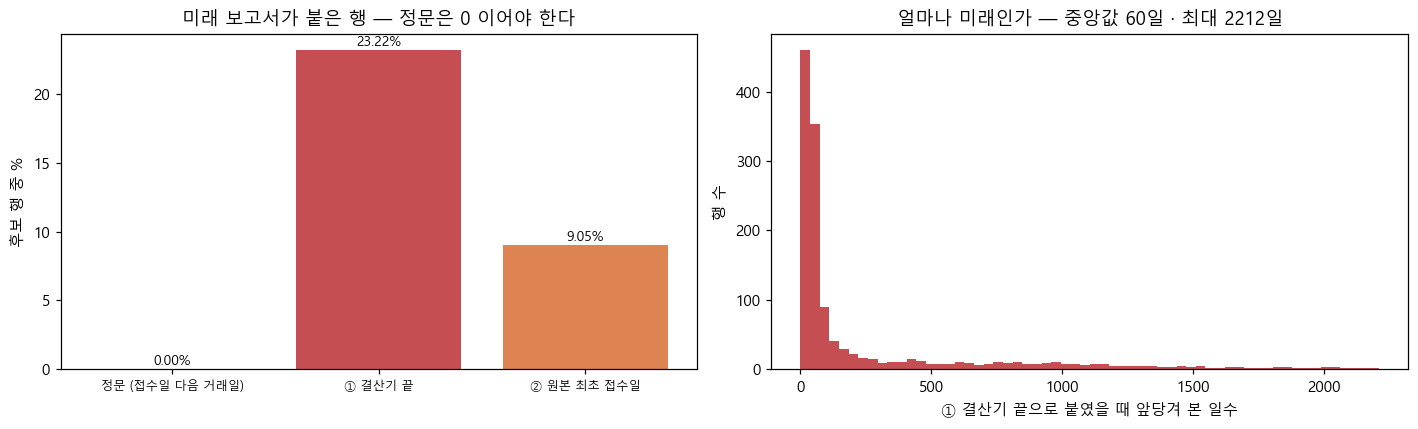

In [9]:
샌날 = 결산기로.loc[결산샘, "bas_dd"]
미래일 = (pd.to_datetime(결산알게된날[결산샘]) - pd.to_datetime(샌날)).dt.days

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.bar(대조["구현"], 대조["후보 행 중 %"], color=["#55A868", "#C44E52", "#DD8452"])
for x, v in enumerate(대조["후보 행 중 %"]):
    ax.text(x, v + 0.3, f"{v:.2f}%", ha="center", fontsize=9)
ax.set_ylabel("후보 행 중 %")
ax.set_title("미래 보고서가 붙은 행 — 정문은 0 이어야 한다")
ax.tick_params(axis="x", labelsize=8)

ax = axes[1]
ax.hist(미래일, bins=60, color="#C44E52")
ax.set_xlabel("① 결산기 끝으로 붙였을 때 앞당겨 본 일수")
ax.set_ylabel("행 수")
ax.set_title(f"얼마나 미래인가 — 중앙값 {미래일.median():.0f}일 · 최대 {미래일.max():.0f}일")
fig.tight_layout()
plt.show()

**결과** — 정문은 미래 보고서가 붙은 행이 **0** 입니다. 같은 후보 행에 결산기 끝으로 붙이면
**23.2%**(1,324행)가, 원본 최초 접수일로 당기면 **9.1%**(516행)가 그날 알 수 없던 보고서를 봅니다.
마지막 표본날에는 정문과 ① 이 **98.0%** 같은 보고서를 붙입니다 — 두 구현이 **고르는 보고서는
대부분 같고 다른 것은 시점**이라는 뜻이고, 그래서 이 대조군이 시점 규칙을 가르는 대조군입니다.

②의 9.1% 가 *"정정본은 정정일까지 안 보인다"* 규칙이 막고 있는 몫입니다. 정정 전 숫자(vintage)를
DART 재무 API 로 받을 수 없어서 이 행들은 채움률 손실로 남깁니다.

---

## 5. 거시 — 발표된 날로 붙이면 값은 얼마나 늦나

`attach_macro` 는 행마다 **그 행의 날짜까지 발표된 것 중 기간이 가장 늦은 값**을 붙입니다.
경기 순환변동치(`leading`·`coincident`)는 과거 값이 개정되는 계열이라 **기본에서 빠지고**,
이름을 적어야 나옵니다. 여기서는 비교를 위해 이름을 적어 아홉 지표를 모두 붙입니다.

아래 "행 날짜 - 기간 시작" 은 **그날 쓸 수 있었던 값이 며칠 전 기간의 것인가** 입니다.

,지표,기본 포함,채움 %,행 날짜 - 기간 시작 중앙값(일)
0,base_rate,True,100.0,60
1,ktb3y,True,100.0,1
2,ktb10y,True,100.0,1
3,usdkrw,True,100.0,1
4,jpykrw,True,100.0,1
5,cpi,True,100.0,60
6,ppi,True,100.0,60
7,leading,False,100.0,90
8,coincident,False,100.0,90


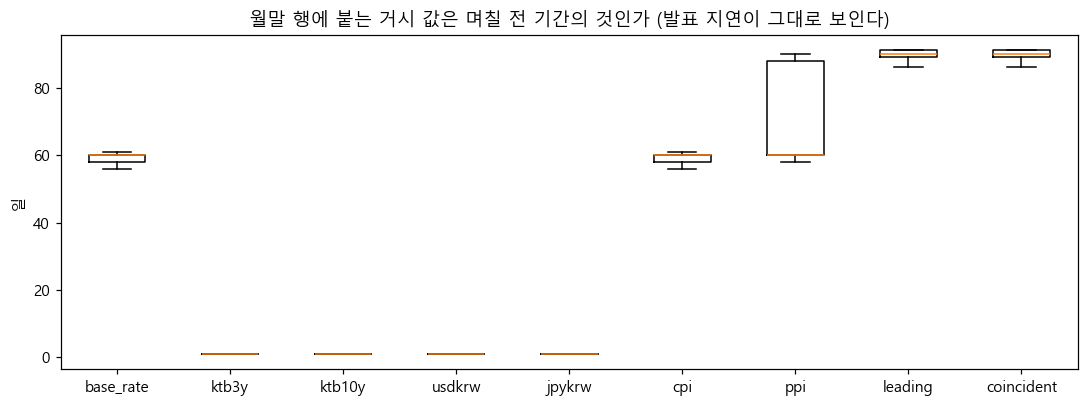

In [10]:
날들 = pd.DataFrame({"bas_dd": 표본날})
전부 = attach_macro(날들, as_of=AS_OF, indicators=macro.ALL_INDICATORS)
기본칸 = attach_macro(날들, as_of=AS_OF).columns
지표표, 지연들 = [], {}
for i in macro.ALL_INDICATORS:
    p = 전부[f"macro_{i}_period"]
    시작 = pd.to_datetime(p.where(p.str.len() == 8, p + "01"), format="%Y%m%d")
    지연 = (pd.to_datetime(전부["bas_dd"]) - 시작).dt.days
    지연들[i] = 지연.dropna()
    지표표.append({"지표": i, "기본 포함": f"macro_{i}" in 기본칸,
                  "채움 %": round(p.notna().mean() * 100, 1),
                  "행 날짜 - 기간 시작 중앙값(일)": int(지연.median())})
display(pd.DataFrame(지표표))

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.boxplot([지연들[i] for i in macro.ALL_INDICATORS], showfliers=False)
ax.set_xticks(range(1, len(macro.ALL_INDICATORS) + 1), labels=list(macro.ALL_INDICATORS))
ax.set_ylabel("일")
ax.set_title("월말 행에 붙는 거시 값은 며칠 전 기간의 것인가 (발표 지연이 그대로 보인다)")
fig.tight_layout()
plt.show()

**결과** — 아홉 지표 모두 **100%** 채워집니다(거시는 2009-08 부터 받아 둔 덕입니다). 월말 행에 붙는
값은 일별 지표가 **1일** 전, 기준금리·CPI·PPI 가 기간 시작 기준 중앙값 **60일**, 경기지수가 **90일**
전 기간의 것입니다. 기준월 1일로 붙였다면 월말 행에 **그달 값**이 붙었을 것이고, 그 값은 그날
아직 발표되지 않았습니다.

---

## 6. 공시 텍스트 — 그날 새로 보인 공시

`attach_text` 는 (종목, 일)마다 **그날 새로 보인 공시**(접수일 다음 거래일 = 그날)의 건수와
제목 감성 확률 평균을 붙입니다. 공시가 없던 날은 0 이고, 수집 구간 밖은 결측입니다.

🔴 이 신호는 5일 방향과 관계가 없습니다(Cramér's V 0.026 · 2026-09-04). 이 문은
*"그날 무슨 공시가 났나"* 를 보는 **이벤트 타임라인**으로 엽니다.

attach_text 5,703행 · 2.0초 · 결측(수집 구간 밖) 0


,그날 새 공시가 있는 후보 %,건수 평균,확률 붙음 %
bas_dd,,,
2015,23.10,0.44,23.10
2016,30.10,0.54,30.10
2017,22.74,0.62,22.74
2018,20.07,0.37,20.07
2019,20.41,0.36,20.41
2020,30.10,0.61,30.10
2021,25.55,0.54,25.55
2022,27.83,0.62,27.83
2023,27.83,0.50,27.83


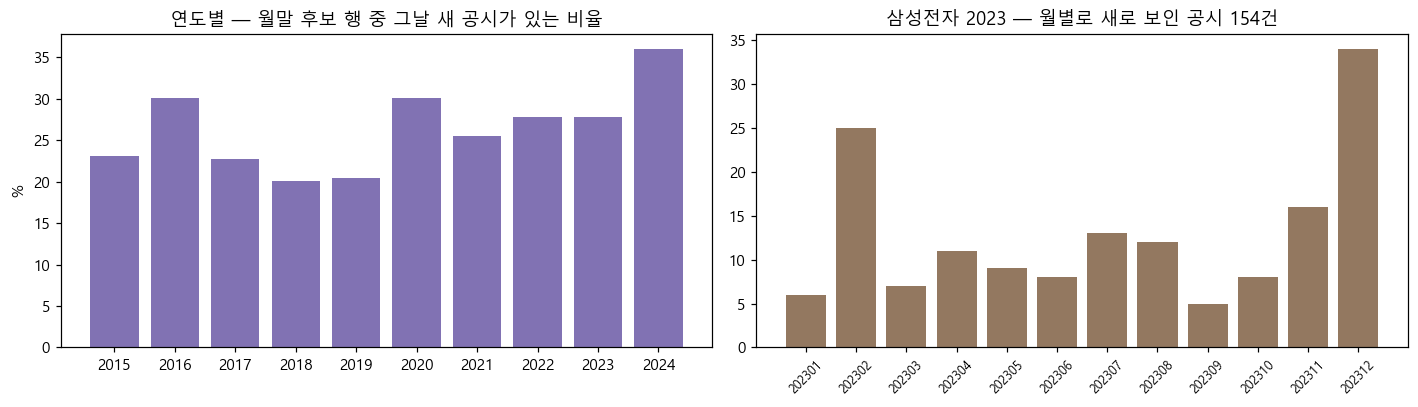

In [11]:
t0 = time.time()
텍스트 = attach_text(후보[["bas_dd", "code"]], as_of=AS_OF)
print(f"attach_text {len(텍스트):,}행 · {time.time() - t0:.1f}초 · "
      f"결측(수집 구간 밖) {텍스트['text_n'].isna().sum()}")
해 = 텍스트["bas_dd"].str[:4]
연도별텍스트 = pd.DataFrame({
    "그날 새 공시가 있는 후보 %": 텍스트["text_n"].gt(0).groupby(해).mean() * 100,
    "건수 평균": 텍스트["text_n"].astype(float).groupby(해).mean(),
    "확률 붙음 %": 텍스트["text_p_pos"].notna().groupby(해).mean() * 100,
}).round(2)
display(연도별텍스트)

삼성 = text_as_of("20231228", as_of="2024-01-01", start="20230102", codes=["005930"])
월별 = 삼성.groupby(삼성["known_at"].str[:6]).agg(n=("rcept_no", "size"), p_neg=("p_neg", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(연도별텍스트.index, 연도별텍스트["그날 새 공시가 있는 후보 %"], color="#8172B3")
axes[0].set_ylabel("%")
axes[0].set_title("연도별 — 월말 후보 행 중 그날 새 공시가 있는 비율")
axes[1].bar(월별.index, 월별["n"], color="#937860")
axes[1].set_title(f"삼성전자 2023 — 월별로 새로 보인 공시 {len(삼성)}건")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
fig.tight_layout()
plt.show()

**결과** — 월말 후보 행 중 그날 새 공시가 있는 행은 **20~36%** 이고, 공시가 있는 행에는 확률이
**모두** 붙습니다(제목 점수가 공시 155만 행에 100% 조인). 수집 구간 밖 결측은 개발구간에서 0 입니다.

---

## 7. 하루 누수를 고치면 팀 유니버스가 얼마나 바뀌나

오늘 업종·주권종류 붙이기를 **그 행의 날짜까지 알게 된 것**으로 고쳤습니다. 예전에는 날짜로
조인해서, `as_of` 를 넉넉히 주는 반출 경로에서 **그날 마감 뒤에 나온 표가 그날 행에 붙었습니다.**

- 업종 스냅샷 당일 40,857행 중 **5,300행**이 새 정보를 하루 먼저 봤다 (처음 실림 3,630 · 업종 바뀜 1,670)
- 주권종류는 소속부가 바뀐 날 **6,276행**(관리종목 지정 포함) · 상장 첫날 **3,677행**

업종이 바뀌는 날은 **스냅샷 날**뿐이므로 그날들에서 후보를 두 규칙으로 만들어 비교합니다.
예전 규칙은 이 셀에서 따로 짭니다(고친 코드를 되돌리지 않고).

,스냅샷날,예전 후보,고친 뒤 후보,빠진 종목,들어온 종목
0,20110103,48,48,2,2
1,20120102,48,48,2,2
2,20130102,50,50,0,0
3,20140102,48,48,0,0
4,20150102,48,48,2,2
5,20160104,48,48,1,1
6,20170102,48,48,1,1
7,20180102,49,48,7,6
8,20190102,49,49,0,0
9,20200102,49,49,1,1


스냅샷날 15일 · 후보가 바뀐 날 12일 · 바뀐 종목 합계 25


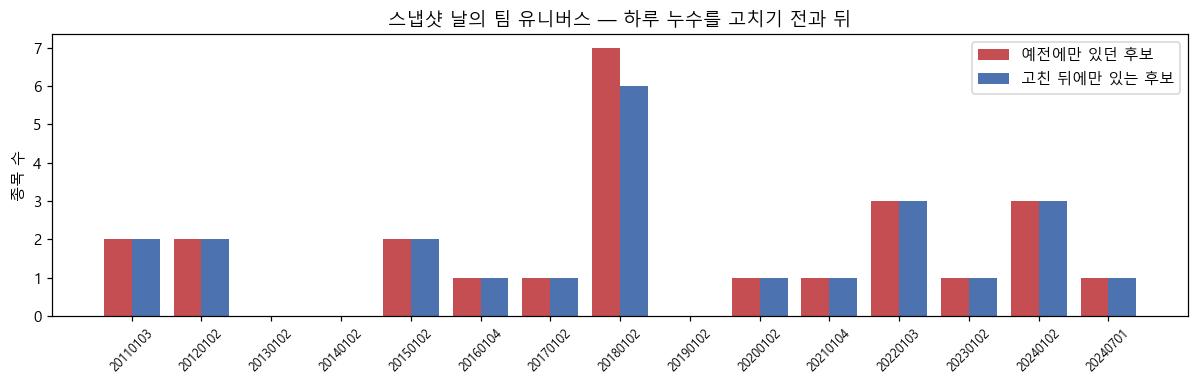

In [12]:
스냅샷 = snapshots()
스냅샷날 = sorted(d for d in 스냅샷["bas_dd"].unique() if "20110101" <= d < HOLDOUT)
d7, i7 = 코스피_시세(스냅샷날)

새것 = 고친_규칙으로_붙인다(d7)

# 예전 규칙 — 스냅샷 날짜로 붙이고, 기본정보는 같은 날짜로 조인한다
옛 = d7.assign(_k=d7["bas_dd"].astype(int)).sort_values("_k")
오른 = (resolve_duplicates(스냅샷)
         .assign(_k=lambda f: f["bas_dd"].astype(int))
         .rename(columns={"sector_nm": "industry"})[["_k", "code", "industry"]]
         .sort_values("_k"))
옛 = pd.merge_asof(옛, 오른, on="_k", by="code", direction="backward").drop(columns="_k")
자리 = ",".join("?" * len(스냅샷날))
기본정보 = pd.read_sql_query(
    f"SELECT bas_dd, code, kind_stkcert_tp_nm FROM stock_base_info WHERE bas_dd IN ({자리})",
    con, params=스냅샷날)
옛 = 옛.merge(기본정보, on=["bas_dd", "code"], how="left")

후보새 = build_sector_candidate_frame(새것, i7, holdout_start=HOLDOUT)
후보옛 = build_sector_candidate_frame(옛, i7, holdout_start=HOLDOUT)
비교 = []
for d in 스냅샷날:
    a = set(후보옛.loc[후보옛["bas_dd"] == d, "code"])
    b = set(후보새.loc[후보새["bas_dd"] == d, "code"])
    비교.append({"스냅샷날": d, "예전 후보": len(a), "고친 뒤 후보": len(b),
                 "빠진 종목": len(a - b), "들어온 종목": len(b - a)})
비교 = pd.DataFrame(비교)
display(비교)
print(f"스냅샷날 {len(스냅샷날)}일 · 후보가 바뀐 날 {(비교['빠진 종목'] > 0).sum()}일 · "
      f"바뀐 종목 합계 {비교['빠진 종목'].sum()}")

fig, ax = plt.subplots(figsize=(11, 3.6))
x = np.arange(len(비교))
ax.bar(x - 0.2, 비교["빠진 종목"], width=0.4, color="#C44E52", label="예전에만 있던 후보")
ax.bar(x + 0.2, 비교["들어온 종목"], width=0.4, color="#4C72B0", label="고친 뒤에만 있는 후보")
ax.set_xticks(x, labels=비교["스냅샷날"], rotation=45, fontsize=8)
ax.set_ylabel("종목 수")
ax.set_title("스냅샷 날의 팀 유니버스 — 하루 누수를 고치기 전과 뒤")
ax.legend()
fig.tight_layout()
plt.show()

**결과** — 스냅샷 날 15일 중 **12일**에서 후보가 바뀌고, 바뀐 종목은 합계 **25종목**입니다
(가장 많은 날은 2018-01-02 의 7종). 🔴 조합 K 피처는 업종을 쓰지 않으므로 피처 **값은 그대로**이고
**어느 행이 표본에 들어가는지**만 바뀝니다. 그래도 개봉 전 동결 원칙상 HF 반출본을 다시 올리고
최종모델 드라이런을 다시 해야 합니다 — 이슈 #240.

---

## 8. 피처 파트는 이렇게 쓰면 된다

정문은 **그날 알 수 있었던 원값**까지만 냅니다. 값을 피처로 만드는 것은 피처 파트의 몫입니다.

```python
from supply import attach_financial, attach_macro, attach_text

panel = attach_financial(prices, as_of=AS_OF)   # 재무 18칸 (메타 9 · 계정 9)
panel = attach_macro(panel, as_of=AS_OF)        # 지표마다 값·기간 두 칸 (기본 7지표)
panel = attach_text(panel, as_of=AS_OF)         # text_n · text_p_neg/neu/pos
```

| 하고 싶은 것 | 이렇게 | 조심할 것 |
|---|---|---|
| ROE · 부채비율 | `fin_net_income_parent / fin_equity_parent` 처럼 원값으로 계산 | 분모 결측·0 · 지배지분이 빈 보고서가 있다 |
| 오래된 재무 거르기 | `(bas_dd - fin_period_end).days > 456` | 정정본은 정정일까지 안 보인다 |
| 다른 계정 | `financial_lines_as_of(..., codes=...)` 의 `account_key` | 접두어는 이미 떼어 두었다 |
| 물가 전년 대비 | `macro_history("cpi", as_of=...)` 에서 기간끼리 | 결과의 시점은 **늦은 기간의 known_at** |
| 경기 순환변동치 | `indicators=("leading",)` 로 이름을 적는다 | 과거 값이 개정된 2026-09 판이다 |
| 공시 창 합계 | `text_n` 을 종목별 롤링 합 | 확률은 신호가 없다(V 0.026) |

후보 표(`build_sector_candidate_frame`)의 `code` 가 pandas `string` 이어도 다섯 `attach_*` 는 돈다.

In [13]:
예시 = 후보.loc[후보["bas_dd"] == 후보["bas_dd"].max(), ["bas_dd", "code", "name"]].head(3)
예시 = attach_financial(예시, as_of=AS_OF)
예시 = attach_macro(예시, as_of=AS_OF)
예시 = attach_text(예시, as_of=AS_OF)
예시["roe"] = 예시["fin_net_income_parent"] / 예시["fin_equity_parent"]
display(예시.T)

,5653,5654,5655
bas_dd,20240830,20240830,20240830
code,005930,000660,373220
name,삼성전자,SK하이닉스,LG에너지솔루션
fin_bsns_year,2023,2023,2023
fin_reprt_code,11011,11011,11011
fin_fs_div,CFS,CFS,CFS
fin_period_end,20231231,20231231,20231231
fin_rcept_no,20240312000736,20240319000684,20240314001110
fin_rcept_dt,20240312,20240319,20240314
fin_known_at,20240313,20240320,20240315


---

## 9. 남은 것

- **재무는 사업보고서만** 있다 — 분기·반기(11012·11013·11014)를 받으면 정문은 그대로 쓴다
  (`REPORT_ORDER` 가 결산 순서를 이미 안다)
- **정정 전 판(vintage)** 은 DART 재무 API 로 받을 수 없다 — XBRL 원문 파싱이 필요하다
- **거시 옛 판** 이 없다 — 받을 때마다 `raw_response` 에 원문을 쌓으면 다음부터는 개정을 잴 수 있다
- 반출본(HF)의 업종·주권종류 칸은 **하루 누수 수정 전 값**이다 — 재배포한다(#240)
- 재무·거시·텍스트를 **반출(HF)에 실을지** 는 아직 정하지 않았다

In [14]:
con.close()
print("끝 — 연결을 닫았다")

끝 — 연결을 닫았다
